✅ City Road Network Map generated successfully in 8 attempts!


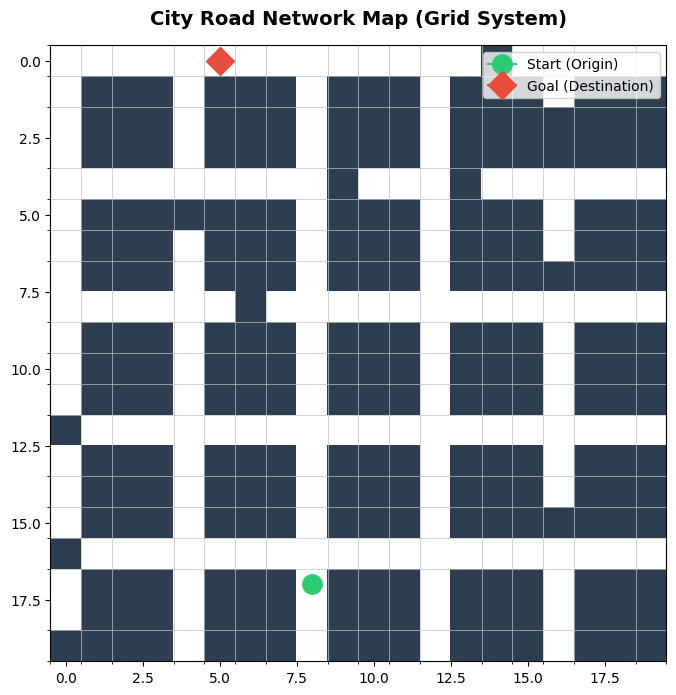

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration Class
class Config:
    MAZE_SIZE = 20          # 20x20 Grid size city map ke liye best hai
    STREET_SPACING = 4      # Har 4 blocks baad ek road (Grid system)

# 2. Road Maze Generator Class
class RoadMazeGenerator:
    @staticmethod
    def count_distinct_paths(maze, start, goal, max_paths_to_find=5):
        """ BFS/DFS algorithm yeh check karne ke liye ki Start se Goal tak valid rasta hai ya nahi """
        size = maze.shape[0]
        paths_found = 0
        visited = np.zeros_like(maze, dtype=bool)

        def dfs(curr):
            nonlocal paths_found
            if paths_found >= max_paths_to_find: return
            if curr == goal:
                paths_found += 1
                return

            r, c = curr
            for r_off, c_off in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + r_off, c + c_off
                if 0 <= nr < size and 0 <= nc < size:
                    if maze[nr, nc] == 0 and not visited[nr, nc]:
                        visited[nr, nc] = True
                        dfs((nr, nc))
                        visited[nr, nc] = False

        visited[start[0], start[1]] = True
        dfs(start)
        return paths_found

    @classmethod
    def generate_road_network(cls, size, spacing):
        """ Proper grid system par adharit horizontal aur vertical roads generate karne wala function """
        attempts = 0
        while True:
            attempts += 1
            # 1 = Buildings/Blocks, 0 = Roads
            maze = np.ones((size, size), dtype=int)

            # Horizontal aur Vertical Roads draw karna (City Grid Layout)
            for r in range(0, size, spacing): maze[r, :] = 0
            for c in range(0, size, spacing): maze[:, c] = 0

            # 10% random blocks roads par taake map natural lage (Dead ends create karne ke liye)
            for r in range(size):
                for c in range(size):
                    if maze[r, c] == 0 and (r % spacing != 0 and c % spacing != 0):
                        pass # Intersections ko block nahi karna
                    elif maze[r, c] == 0 and random.random() < 0.10:
                        maze[r, c] = 1

            # Khali sarak (0) se random Start aur Goal select karna
            road_coords = [(r, c) for r in range(size) for c in range(size) if maze[r, c] == 0]
            if len(road_coords) < 2: continue

            start, goal = random.sample(road_coords, 2)

            # Distance check (Start aur Goal door hone chahiye taake lamba sarak network mile)
            manhattan_dist = abs(start[0] - goal[0]) + abs(start[1] - goal[1])
            if manhattan_dist >= (size // 1.2):
                paths = cls.count_distinct_paths(maze, start, goal, max_paths_to_find=5)
                if paths >= 5:
                    print(f"✅ City Road Network Map generated successfully in {attempts} attempts!")
                    return maze, start, goal

# 3. Graphical Visualization Function
def plot_road_map(maze, start, goal):
    size = maze.shape[0]

    # Plotting setup (Fig Size 8x8 tak rakhha hai taake grid saaf dikhe)
    fig, ax = plt.subplots(figsize=(8, 8))

    # Custom colormap: 0 = White (Roads), 1 = Dark Blue/Grey (Buildings)
    cmap = plt.cm.colors.ListedColormap(['#FFFFFF', '#2C3E50'])
    ax.imshow(maze, cmap=cmap, origin='upper')

    # Start (Green Circle) aur Goal (Red Diamond) ke markers
    ax.plot(start[1], start[0], marker='o', color='#2ECC71', markersize=14, label='Start (Origin)')
    ax.plot(goal[1], goal[0], marker='D', color='#E74C3C', markersize=14, label='Goal (Destination)')

    # Grid lines settings taake proper blocks aur lanes nazar aayein
    ax.set_xticks(np.arange(-0.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, size, 1), minor=True)
    ax.grid(which='minor', color='#BDC3C7', linestyle='-', linewidth=0.5)

    # Title aur Labels
    plt.title("City Road Network Map (Grid System)", fontsize=14, fontweight='bold', pad=15)
    plt.legend(loc='upper right')
    ax.axis('on')

    plt.show()

# 4. Main Execution Block
if __name__ == "__main__":
    # Config se variables uthakar generator ko call karna
    size = Config.MAZE_SIZE
    spacing = Config.STREET_SPACING

    # Map generate karna
    maze, start, goal = RoadMazeGenerator.generate_road_network(size, spacing)

    # Graph render karna
    plot_road_map(maze, start, goal)